# Matplotlib study

[Matplotlib doc](https://matplotlib.org/stable/index.html)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
import librosa
import librosa.display
from sklearn.preprocessing import minmax_scale

sys.path.insert(0, os.path.abspath('..'))
from dataprocess.cwt.cwt2 import cwt2, rd_file, cwt3
from dataprocess.util.data_process import replace_zeroes

from IPython.display import Audio

DATA_DIR = '../data/sound/grasshopper-sound-4/'
CMAP = 'magma'

In [2]:
fn = f'{DATA_DIR}gh-4_mono_denoised_filter.wav'
d1, sr1, dura1 = rd_file(fn)
Audio(d1, rate=sr1)

In [8]:
F_MAX = sr1 // 2
S = librosa.feature.melspectrogram(y=d1, sr=sr1, n_mels=256, fmax=F_MAX)
S_db = librosa.power_to_db(S, ref=np.max)

d2, sr2 = librosa.load(fn)
d2 = minmax_scale(d2 - d2.mean(), feature_range=(-1,1))
cs1, f1 = cwt2(d2, nv=12, sr=sr2, low_freq=40)
#cs1, f1 = cwt3(d2, nv=12, sr=sr2, low_freq=40)
print(f'shape of cs1: {cs1.shape}')
print(f'cs1:\n{cs1[10][52000:52020]}')
print(f'shape of f1: {f1.shape}')

shape of cs1: (97, 228217)
cs1:
[ 6.37908006e-05-2.80962154e-05j  1.89700197e-05+6.27934892e-05j
 -5.53024992e-05+1.36298411e-05j -1.20236643e-05-4.34747858e-05j
  3.04969865e-05-1.32683169e-05j  1.58347790e-05+1.97609403e-05j
 -1.37575255e-05+1.76871162e-05j -1.66182836e-05-1.30639092e-05j
  1.59576529e-05-1.09165227e-05j  1.66922348e-07+1.90017823e-05j
 -1.84537345e-05-1.42526049e-05j  2.93547620e-05-1.18712895e-05j
 -8.45534530e-07+4.14378620e-05j -4.73518380e-05-1.74383675e-05j
  3.42394349e-05-4.56192345e-05j  3.69706328e-05+4.75983267e-05j
 -5.51617021e-05+2.40873546e-05j -1.06249133e-05-5.65200942e-05j
  5.30281347e-05+1.44055743e-07j -6.53896175e-06+4.69338012e-05j]
shape of f1: (97,)


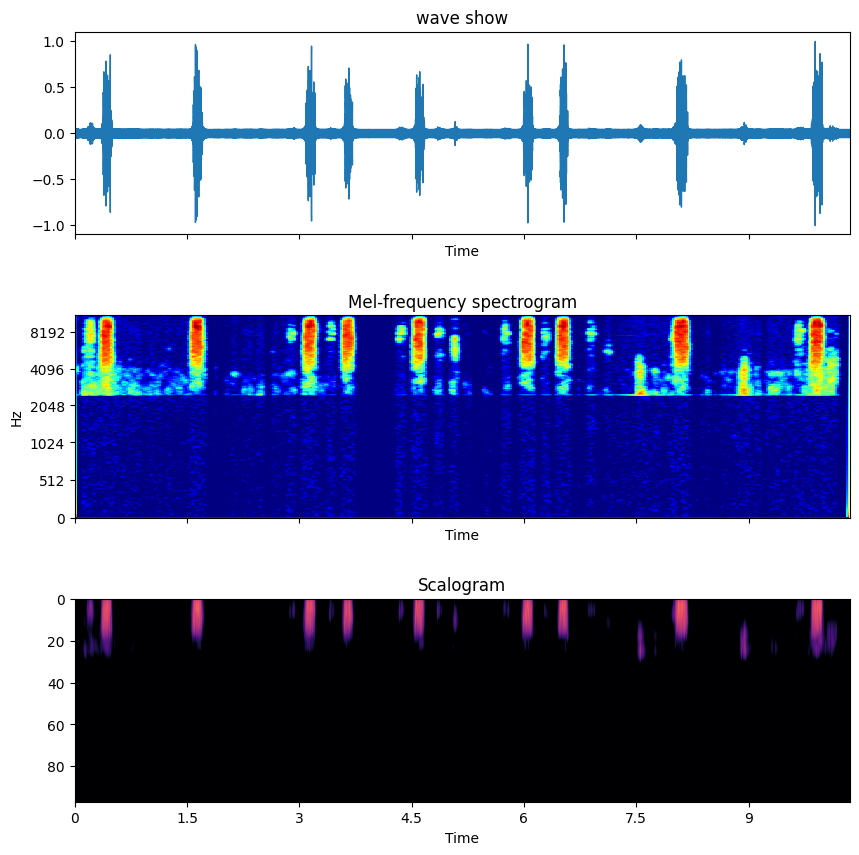

In [15]:
#fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=True)
fig, axes = plt.subplots(3, 1, figsize=(10,10), sharex=False)

librosa.display.waveshow(y=d1, sr=sr1, ax=axes[0])
axes[0].set(title='wave show')

img = librosa.display.specshow(S_db, x_axis='time', y_axis='mel', sr=sr1, fmax=F_MAX, cmap='jet', ax=axes[1])
# fig.colorbar(img, ax=axes[1], format='%+2.0f dB')
axes[1].set(title='Mel-frequency spectrogram')

cs1 = replace_zeroes(cs1)
axes[2].imshow(20*np.log10(np.abs(cs1)), cmap=CMAP, aspect='auto', norm=None, 
    vmax=0, vmin=-60,
    #extent=[0.0, dura1, cs1.shape[0], 0]
)
axes[2].set_xlabel('Time')
axes[2].set(title='Scalogram')

fig.subplots_adjust(hspace=0.4)
plt.show()


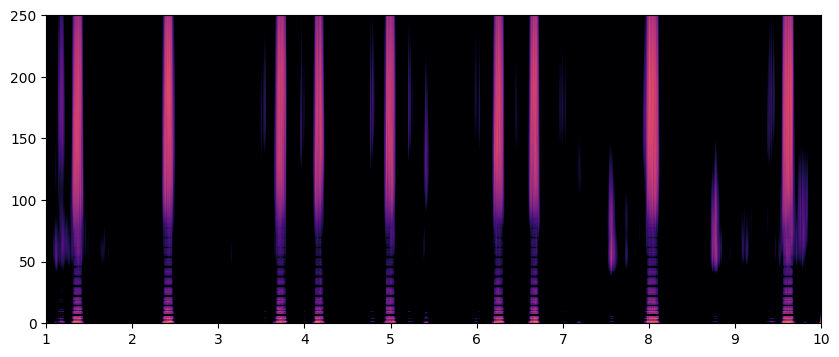

In [6]:
plt.figure(figsize = (10,4))
plt.imshow(20*np.log10(np.abs(cs1)), cmap='magma', aspect='auto', norm=None, vmax=0, vmin=-60, extent=[1.0, 10.0, 0, 250])
#plt.xticks(np.linspace(0.0, 10.0, len(cs1[0])))